# EXAMEN BIMESTRAL: SISTEMAS DE INFORMACIÓN DE RECURSOS HUMANOS (HRIS)
**Estudiante:** Michael Ramos  
**Asignatura:** Introducción a los Sistemas de Información  
**Fecha:** 5/6/2026  
**Base de datos utiliazda:** WA_Fn-UseC_-HR-Employee-Attrition.csv

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Configuracion de estilo global para Matplotlib estandar
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 5)

# Cargar el dataset provisto
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

## KPI 1: Tasa de Rotación de Personal (Attrition Rate)
**Objetivo:** Medir el porcentaje de deserciones voluntarias en la organización para evaluar la perdida de personal.
* **Fórmula:** (Empleados con Attrition 'Yes' / Total de Empleados) * 100
* **Gráfico seleccionado:** Gráfico de Pastel, mejor para representar la proporción de un todo

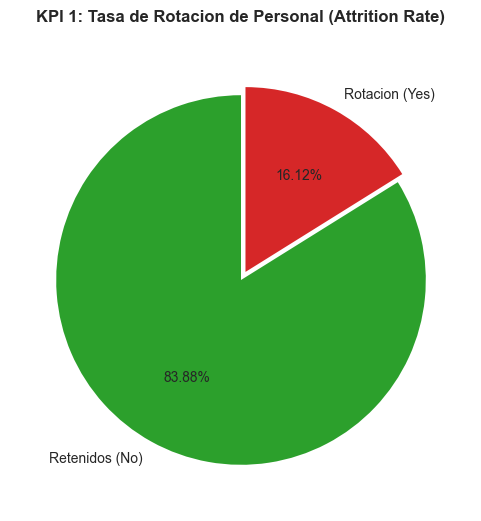

Resultados del analisis: Tasa de Rotacion del 16.12% (237 deserciones de 1470 empleados).


In [30]:
attrition_counts = df['Attrition'].value_counts()
labels = ['Retenidos (No)', 'Rotacion (Yes)']
colors_kpi1 = ['#2ca02c', '#d62728']

plt.figure(figsize=(6, 6))
plt.pie(attrition_counts, labels=labels, autopct='%1.2f%%', startangle=90, colors=colors_kpi1, explode=(0, 0.05))
plt.title('KPI 1: Tasa de Rotacion de Personal (Attrition Rate)', fontsize=12, fontweight='bold', pad=20)
plt.show()


total_emp = len(df)
yes_emp = attrition_counts.get('Yes', 0)
print(f"Resultados del analisis: Tasa de Rotacion del { (yes_emp / total_emp) * 100:.2f}% ({yes_emp} deserciones de {total_emp} empleados).")

## KPI 2: Ingreso Promedio Mensual por Departamento
**Objetivo:** Comparar los sueldos promedio entre los departamentos de la empresa para identificar desigualdades salariales.
* **Formula:** Promedio de la variable `MonthlyIncome` agrupado por `Department`.
* **Grafico seleccionado:** Grafico de Barras Verticales, ideal para diferenciar montos financieros entre pequeñas categorias.

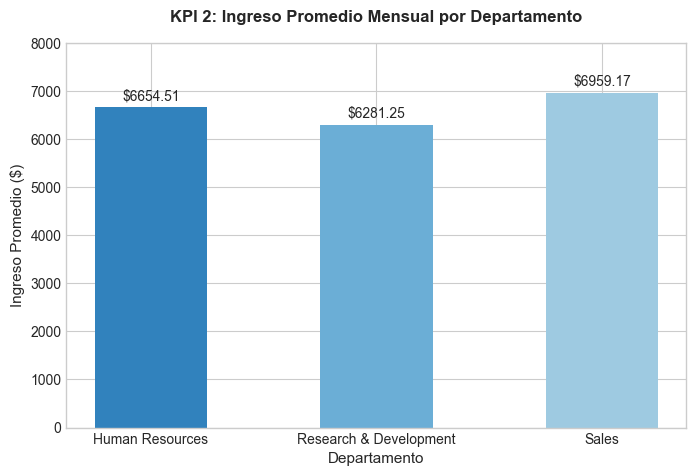

In [31]:
kpi2_df = df.groupby('Department')['MonthlyIncome'].mean().reset_index()

plt.figure(figsize=(8, 5))
colors_kpi2 = ['#3182bd', '#6baed6', '#9ecae1']
bars2 = plt.bar(kpi2_df['Department'], kpi2_df['MonthlyIncome'], color=colors_kpi2, width=0.5)
plt.title('KPI 2: Ingreso Promedio Mensual por Departamento', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Departamento', fontsize=11)
plt.ylabel('Ingreso Promedio ($)', fontsize=11)

for bar in bars2:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 100, f"${yval:.2f}", ha='center', va='bottom', fontsize=10)

plt.ylim(0, kpi2_df['MonthlyIncome'].max() * 1.15) 
plt.show()

## KPI 3: Índice de Balance Vida-Trabajo (Work-Life Balance Promedio) por Cargo
**Objetivo:** Evaluar la calidad del entorno laboral y los riesgos del personal operativo. Este nos permite identificar de forma temprana cuales roles sufren sobrecarga para prevenir futuras deserciones.
* **Fórmula:** Promedio de la variable `WorkLifeBalance` (escala 1 al 4) agrupado por `JobRole`.
* **Gráfico seleccionado:** Gráfico de Barras Horizontales, el cual facilita la lectura limpia de etiquetas largas cuando se tienen múltiples categorías (9 cargos diferentes).

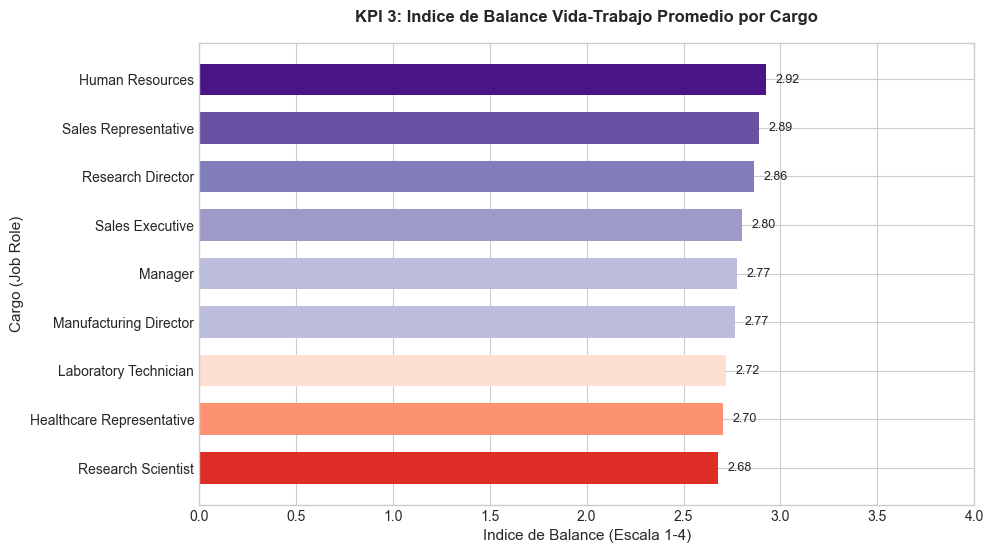

In [32]:
kpi3_df = df.groupby('JobRole')['WorkLifeBalance'].mean().reset_index().sort_values(by='WorkLifeBalance')

plt.figure(figsize=(10, 6))

colors_kpi3 = ['#de2d26', '#fc9272', '#fee0d2', '#bcbddc', '#bcbddc', '#9e9ac8', '#807dba', '#6a51a3', '#4a1486']

bars3 = plt.barh(kpi3_df['JobRole'], kpi3_df['WorkLifeBalance'], color=colors_kpi3, height=0.65)
plt.title('KPI 3: Indice de Balance Vida-Trabajo Promedio por Cargo', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Indice de Balance (Escala 1-4)', fontsize=11)
plt.ylabel('Cargo (Job Role)', fontsize=11)
plt.xlim(0, 4)

for bar in bars3:
    xval = bar.get_width()
    plt.text(xval + 0.05, bar.get_y() + bar.get_height()/2.0, f"{xval:.2f}", ha='left', va='center', fontsize=9)

plt.show()

## KPI 4: Brecha de Estancamiento Laboral (Puesto Actual vs. Ultima Promocion)
**Objetivo:** Analizar la fluidez de las lineas de carrera internas. Una brecha positiva donde los años en el puesto actual superan el tiempo transcurrido desde la ultima promocion delata estancamiento operativo, vinculandose a perdidas de productividad.
* **Formula:** Promedio de `YearsInCurrentRole` comparado en paralelo frente al promedio de `YearsSinceLastPromotion`.
* **Grafico seleccionado:** Grafico de Barras Agrupadas/Comparativas, la mejor para contrastar dos grupos sobre una misma categoria.

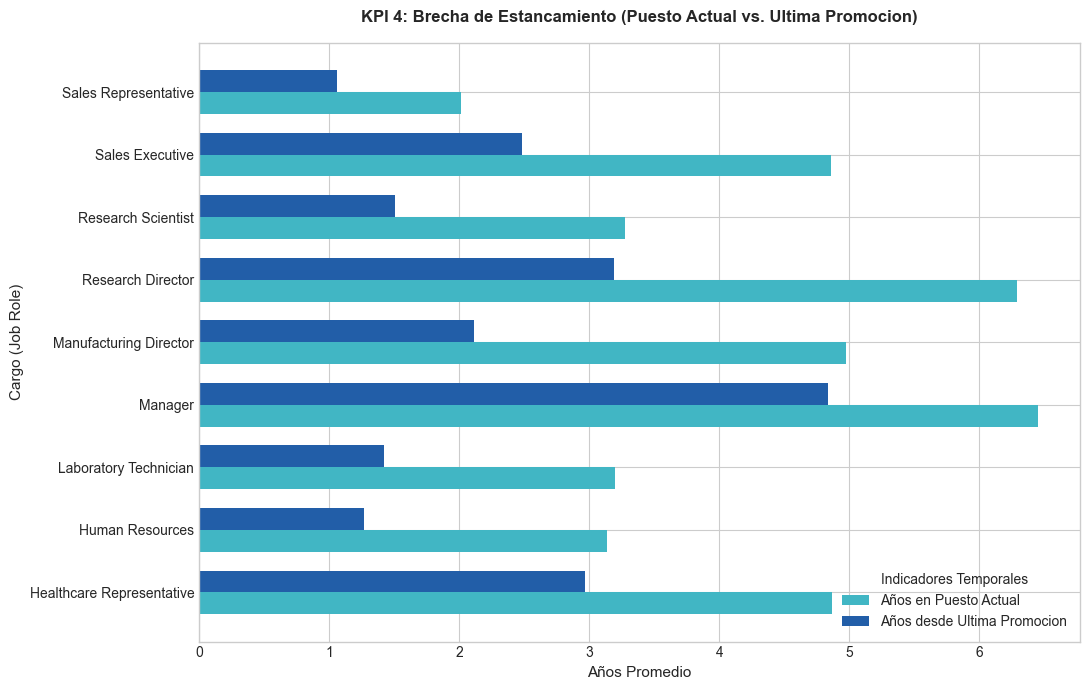

Años promedio general en Puesto Actual: 4.23 años
Años promedio general desde Ultima Promocion: 2.19 años
Brecha Organizacional Neta: 2.04 años


In [33]:
kpi4_df = df.groupby('JobRole')[['YearsInCurrentRole', 'YearsSinceLastPromotion']].mean().reset_index()

y_positions = np.arange(len(kpi4_df['JobRole']))
bar_width = 0.35

plt.figure(figsize=(11, 7))

plt.barh(y_positions - bar_width/2, kpi4_df['YearsInCurrentRole'], height=bar_width, label='Años en Puesto Actual', color='#41b6c4')
plt.barh(y_positions + bar_width/2, kpi4_df['YearsSinceLastPromotion'], height=bar_width, label='Años desde Ultima Promocion', color='#225ea8')

plt.yticks(y_positions, kpi4_df['JobRole'])
plt.title('KPI 4: Brecha de Estancamiento (Puesto Actual vs. Ultima Promocion)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Años Promedio', fontsize=11)
plt.ylabel('Cargo (Job Role)', fontsize=11)
plt.legend(loc='lower right', title='Indicadores Temporales')

plt.tight_layout()
plt.show()

print(f"Años promedio general en Puesto Actual: {df['YearsInCurrentRole'].mean():.2f} años")
print(f"Años promedio general desde Ultima Promocion: {df['YearsSinceLastPromotion'].mean():.2f} años")
print(f"Brecha Organizacional Neta: {df['YearsInCurrentRole'].mean() - df['YearsSinceLastPromotion'].mean():.2f} años")

# PARTE 2: REPORTE ESCRITO (ANALISIS Y VALORES NUMERICOS)

A continuacion, se muestran los valores numericos exactos obtenidos a traves de la base de datos del ERP y su respectiva interpretacion desde una perspectiva de analsis informatico

---

### KPI 1: Tasa de Rotacion de Personal (Attrition Rate)
* **Valor Numerico Obtenido:** **16.12%** (Correspondiente a un acumulado historico de 237 deserciones sobre un universo total de 1,470 empleados registrados en el sistema).
* **Interpretacion de Negocio:** Una tasa del 16.12% significa alerta critica que evidencia una fuga considerable de conocimiento y eleva drasticamente los costos de reclutamiento. Este indicador clave de control permite al HRIS programar alarmas analiticas automatizadas para activar planes de retencion antes de que se afecte la continuidad de la empresa.

---

### KPI 2: Ingreso Promedio Mensual por Departamento
* **Valores Numericos Obtenidos:** 
  * **Sales (Ventas):** $6,959.17 mensual.
  * **Human Resources (Recursos Humanos):** $6,654.51 mensual.
  * **Research & Development (Investigacion y Desarrollo):** $6,281.25 mensual.
* **Interpretacion de Negocio:** En este analsis se revela que el area de R&D percibe la compensacion media mas baja de la organizacion, a pesar de ser un pilar de innovacion. Esto nos permite identificar brechas salariales estadisticas y calibrar las bandas de compensacion, garantizando la equidad interna de la empresa.

---

### KPI 3: Indice de Balance Vida-Trabajo Promedio por Cargo
* **Valores Numericos Criticos Obtenidos:** El cargo operativo de **Research Scientist** presenta el indice mas bajo y deficiente con **2.68** (en la escala del 1 al 4), seguido por *Healthcare Representative* con **2.70**. El rol con mejor equilibrio es *Human Resources* con **2.92**.
* **Interpretacion de Negocio:** Los roles analiticos y cientificos de la organizacion estan experimentando los niveles mas agudos de desgaste y sobrecarga operativa dentro del entorno laboral. Integrar esta metrica faculta a la gerencia para implementar politicas de bienestar segmentadas, actuando como una prediccion temprana y eficaz de futuras renuncias voluntarias.

---

### KPI 4: Brecha de Estancamiento Laboral (Puesto Actual vs. Ultima Promocion)
* **Valores Numericos Obtenidos:** A nivel global, la masa laboral activa sufre un excedente de **+2.04 años** de congelamiento (Tiempo en puesto actual: **4.23 años** promedio vs. Tiempo desde ultima promocion: **2.19 años** promedio). En posiciones directivas como **Research Director**, la brecha se agrava alcanzando su punto maximo con **+3.10 años**.
* **Interpretacion de Negocio:** La empresa no está ascendiendo a su personal. Como los empleados llevan más de 2 años atrapados en las mismas tareas sin crecer, se están desmotivando, rinden menos y corren el riesgo de irse si otra empresa les ofrece un mejor puesto.